### Part A - Supervised ML

### Section 1. Import Python Packages

In [3]:
%pip install imbalanced-learn shap


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\pip\__main__.py", line 24, in <module>
    sys.exit(_main())
             ~~~~~^^
  File "H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\pip\_internal\cli\main.py", line 77, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
  File "H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\pip\_internal\commands\__init__.py", line 119, in create_command
    module = importlib.import_module(module_path)
  File "C:\Users\samsung\AppData\Local\Programs\Python\Python313\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_im

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 4.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.0 MB 4.6 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.0 MB 5.5 MB/s eta 0:00:01
   ----------------- ---------------------- 3.4/8.0 MB 4.2 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.0 MB 5.1 MB/s eta 0:00:01
   ---------------------------------- ----- 6.8/8.0 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 5.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.8/36.5 MB 3.2 MB/s eta 0:00:12
   -- ------------------------------------- 2.4/36.5 MB 7.2 MB/s eta 0:00:05
   ---- ----------------------------------- 4.2/36.5 MB 6.2 MB/s eta 0:00:06
   ---- ---------------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, MultiLabelBinarizer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.naive_bayes import BernoulliNB
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# ============================================================
# CONSTANTS
# ============================================================

FILE_PATH   = r"PartA_df.csv"
RANDOM_STATE = 42

LEAKAGE_COL = [
    'diagnosed_mh',
    'current_mh',
    'past_mh',
    'signal_from_clinical',
]

Helper function

1. classify_columns - it helps to identify the type of columns (cate, ordinal, binary, job_spec) later use for imputer
2. class MLBTransformer - this is specifically to process data for job spec (explode & one hot encoding)
3. train_model - pipeline for model on training set and CV results
4. get_feature_names_from_pipe - Extract feature names from the prep step of a fitted pipeline
5. plot_feature_importance - used to plot feature importance map

In [6]:
def classify_columns(X: pd.DataFrame):
    binary_cols      = []
    categorical_cols = []
    ordinal_cols     = []
    job_spec_cols    = []

    for col in X.columns:

        if col == 'job_spec':
            job_spec_cols.append(col)

        elif col.endswith('_missing'):
            # Indicator flags are always 0/1 integers — no imputation needed
            binary_cols.append(col)

        elif (
            pd.api.types.is_object_dtype(X[col]) or
            pd.api.types.is_string_dtype(X[col])
        ):
            # Catches both object and pandas StringDtype / ArrowStringDtype
            categorical_cols.append(col)

        elif set(X[col].dropna().unique()) - {-1} <= {0, 1}:
            # True binary: only 0 and 1 in non-missing, non-MNAR values
            binary_cols.append(col)

        else:
            # Numeric with >2 values: ordinal scales, Age, company_size, etc.
            ordinal_cols.append(col)

    return binary_cols, categorical_cols, ordinal_cols, job_spec_cols

class MLBTransformer(BaseEstimator, TransformerMixin):
    """
    sklearn-compatible wrapper for MultiLabelBinarizer.
    Input: single column of pipe-separated strings or NaN.
    Output: dense 0/1 array with one column per unique job role.
    """
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def _parse(self, X):
        # ColumnTransformer can pass a DataFrame, numpy array, or numpy matrix.
        # The original X[:, 0] fails when pandas receives a tuple slice key
        # during parallel CV (n_jobs=-1). We normalise all input types to a
        # flat 1D numpy array first, then wrap in Series for string operations.
        if isinstance(X, pd.DataFrame):
            arr = X.iloc[:, 0].to_numpy()
        elif isinstance(X, np.ndarray):
            arr = X[:, 0] if X.ndim == 2 else X
        else:
            # fallback: convert whatever it is to numpy first
            arr = np.array(X).flatten()

        s = pd.Series(arr, dtype=object)
        return s.fillna("").astype(str).str.replace("^nan$", "", regex=True).str.split("|").apply(
                    lambda lst: [r.strip().lower() for r in lst if r.strip()]
                )

    def fit(self, X, y=None):
        self.mlb.fit(self._parse(X))
        self.feature_names_ = [
            f"is_{c.replace(' ', '_').replace('/', '_')}"
            for c in self.mlb.classes_
        ]
        return self

    def transform(self, X):
        return self.mlb.transform(self._parse(X)).astype(float)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_)

def train_model(name, model, use_smote, X_tr, y_tr):
    """Build pipeline, run CV, fit on full training set, return pipe."""
    if use_smote:
        pipe = ImbPipeline([
            ("prep",  preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
            ("model", model),
        ])
    else:
        pipe = Pipeline([
            ("prep",  preprocessor),
            ("model", model),
        ])
    cv_scores = cross_val_score(
        pipe, X_tr, y_tr, cv=skf, scoring="recall",
        # n_jobs=1 avoids joblib serialisation issues with the custom
        # MLBTransformer when running X_100 (which includes job_spec).
        # Switch back to n_jobs=-1 if job_spec is not in your dataset version.
        n_jobs=1,
    )
    print(f"  {name} | CV recall: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    pipe.fit(X_tr, y_tr)
    return pipe, cv_scores

def get_feature_names_from_pipe(pipe):
    """Extract feature names from the prep step of a fitted pipeline."""
    try:
        return pipe.named_steps["prep"].get_feature_names_out()
    except Exception as e:
        print(f"  Could not get feature names: {e}")
        return None

def plot_feature_importance(name, pipe, feature_names, top_n=10):
    model_step = pipe.named_steps["model"]

    # Logistic Regression — use coefficients
    if hasattr(model_step, "coef_"):
        coef = model_step.coef_[0]
        if len(coef) != len(feature_names):
            print(f"  {name}: coef length {len(coef)} != features {len(feature_names)} — skipping")
            return
        importance = pd.Series(coef, index=feature_names).sort_values(key=abs, ascending=False)
        title = f"Top {top_n} features (|coef|) — {name}"
        color = importance.head(top_n).map(lambda v: "steelblue" if v >= 0 else "tomato")

    # Decision Tree — use feature importances
    elif hasattr(model_step, "feature_importances_"):
        imp = model_step.feature_importances_
        if len(imp) != len(feature_names):
            print(f"  {name}: importance length {len(imp)} != features {len(feature_names)} — skipping")
            return
        importance = pd.Series(imp, index=feature_names).sort_values(ascending=False)
        title = f"Top {top_n} features (importance) — {name}"
        color = "steelblue"

    else:
        print(f"  {name}: no coef_ or feature_importances_ — skipping ({type(model_step).__name__})")
        return

    top = importance.head(top_n)
    print(f"\n{title}:")
    print(top.to_string())

    # Bar chart
    fig, ax = plt.subplots(figsize=(8, top_n * 0.35 + 1))
    top[::-1].plot(kind="barh", ax=ax, color=color if isinstance(color, str) else color[::-1].values)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Coefficient value" if hasattr(model_step, "coef_") else "Feature importance")
    ax.axvline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()


prepare dataset for ML

In [7]:
# load and drop null and leakage columns
combine_df = pd.read_csv(FILE_PATH, index_col=0)
combine_df = combine_df.dropna(axis=1, how='all')
combine_df = combine_df.drop(columns=LEAKAGE_COL, errors='ignore')

print(f"Shape after drop: {combine_df.shape}")

# ============================================================
# STEP 2 — age cleaning for supervised ML
# from preprocessing detected outliers: min=0, max=323.
# clip to plausible survey range 16–100.
# ============================================================

if 'Age' in combine_df.columns:
    combine_df['Age'] = pd.to_numeric(combine_df['Age'], errors='coerce')
    combine_df['Age'] = combine_df['Age'].where(
        combine_df['Age'].between(16, 100), other=np.nan
    )
    print(f"Age after clip — min: {combine_df['Age'].min()}, "
          f"max: {combine_df['Age'].max()}, "
          f"missing: {combine_df['Age'].isna().mean()*100:.1f}%")

Shape after drop: (3439, 62)
Age after clip — min: 17.0, max: 99.0, missing: 0.3%


Train-Test split

In [8]:
y = combine_df['adhd'].copy().astype('Int64')

# Drop year in addition to leakage columns.
# EDA showed 2023 has a 66% ADHD signal rate but very small sample concern on the model would learn a spurious year to ADHD association that won't generalise.
X_full = combine_df.drop(columns= ['adhd','year'], errors='ignore')

print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"Full feature shape: {X_full.shape}")


# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts()}")



Target distribution:
adhd
0    2913
1     526
Name: count, dtype: Int64
Full feature shape: (3439, 60)

Train: (2579, 60) | Test: (860, 60)
Train target distribution:
adhd
0    2185
1     394
Name: count, dtype: Int64



**Column Classification for pipeline<br>**
Produces three lists that ColumnTransformer uses to route<br>
each column to the correct transformer.<br>


In [9]:
binary_cols, categorical_cols, ordinal_cols, job_spec_cols = classify_columns(X_train)

print("\nColumn classification (on X_train):")
print(f"  Binary      ({len(binary_cols)}): {binary_cols}")
print(f"  Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"  Ordinal     ({len(ordinal_cols)}): {ordinal_cols}")
print(f"  job_spec    ({len(job_spec_cols)}): {job_spec_cols}")


Column classification (on X_train):
  Binary      (39): ['tech_current', 'tech_previous', 'tech_role', 'anxiety', 'mood', 'eating', 'ocd', 'ptsd', 'personality', 'psychotic', 'dissociative', 'addictive', 'substance_use', 'stress_response', 'mh_treatment_history', 'work_mh_benefits_current', 'discussed_with_coworkers', 'discussed_with_employer', 'discuss_mh_with_prev_employer', 'disclose_mh_clients_business_current', 'disclose_mh_coworkers_current', 'observed_coworker_discuss_mh', 'past_disclose_mh_coworker', 'openly_identified_mh_at_work', 'willing_interview_followup', 'prev_coworker_discussed_mh_with_you', 'other_disorder', 'signal_from_self', 'company_size_missing', 'tech_current_missing', 'tech_role_missing', 'work_mh_benefits_current_missing', 'open_to_discuss_coworkers_missing', 'open_to_discuss_supervisor_current_missing', 'open_to_discuss_supervisor_prev_missing', 'willing_share_family_missing', 'discuss_mh_with_prev_coworkers_missing', 'vicarious_stigma_effect_missing', 'famil


**BUILD PREPROCESSOR (ColumnTransformer)**

All transformers fit during pipe.fit(X_train) only

binary_transformer:
SimpleImputer(mode) only. No scaling — 0/1 values need no scale.
-1 (MNAR "Not Asked") is treated as a valid category by the model.

categorical_transformer:
SimpleImputer(mode) to handle any remaining NaN in string cols,
then OrdinalEncoder. <br> This replaces the LabelEncoder that
previously caused data leakage by fitting on the full dataset.
handle_unknown="use_encoded_value" + unknown_value=-2 means
any unseen category in X_test gets -2 instead of an error.<br>

ordinal_transformer:
IterativeImputer (MICE) for statistically sound imputation of
numeric columns with remaining NaN (company_size, tech_current,
work_mh_benefits_current, etc.), then StandardScaler.

mlb_transformer:
Custom MLBTransformer for job_spec


In [10]:
binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-2,
    )),
])

ordinal_transformer = Pipeline([
    ("imputer", IterativeImputer(max_iter=20, random_state=RANDOM_STATE)),
    ("scaler",  StandardScaler()),
])

transformers = [
    ("binary",      binary_transformer,      binary_cols),
    ("categorical", categorical_transformer, categorical_cols),
    ("ordinal",     ordinal_transformer,     ordinal_cols),
]

if job_spec_cols:
    transformers.append(("job_spec", MLBTransformer(), job_spec_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False,
)



### Supervised Machine learning work flow
Phase 1 - With a fixed algorithm (Logistic Regression with L1) to test various imbalance method<br>
Goal: identify which imbalance technique works best before testing other algorithms with it<br>

Phase 2 - Wtih best imbalance method carry forward to test best model<br>

Phase 3 - Sensitivty analysis with the best model<br>

Phase 4 - Ablation study<br>
Note: this can be rerun by from uncomment out at the top

In [11]:
# customised weight is dynamic from target variable y
customised_weight = 1 / y.value_counts(1)[1] - 1
weights = {0: 1, 1: customised_weight}

# ── PHASE 1: Fix LR, vary imbalance method ──────────────────

phase1_models = {

    # True baseline — no imbalance correction at all
    "LR_baseline": LogisticRegression(
        penalty="l1", solver="liblinear",
        class_weight=None, max_iter=1000, C=1, random_state=RANDOM_STATE,
    ),

    # Weight only — sklearn balanced formula
    "LR_balanced": LogisticRegression(
        penalty="l1", solver="liblinear",
        class_weight="balanced", max_iter=1000, C=1, random_state=RANDOM_STATE,
    ),

    # Compare against "balanced" to validate EDA-derived weight
    "LR_weighted": LogisticRegression(
        penalty="l1", solver="liblinear",
        class_weight=weights, max_iter=1000, C=1, random_state=RANDOM_STATE,
    ),

    # SMOTE only — no class_weight, let oversampling do the work alone
    "LR_smote_only": LogisticRegression(
        penalty="l1", solver="liblinear",
        class_weight=None, max_iter=1000, C=1, random_state=RANDOM_STATE,
    ),

    # Combined — class_weight + SMOTE together
    # Expected to confirm redundancy observed in initial baseline
    "LR_combined": LogisticRegression(
        penalty="l1", solver="liblinear",
        class_weight="balanced", max_iter=1000, C=1, random_state=RANDOM_STATE,
    ),
}

# Which phase1 models need SMOTE in the pipeline
phase1_use_smote = {
    "LR_baseline":    False,
    "LR_balanced":    False,
    "LR_weighted":    False,
    "LR_smote_only":  True,
    "LR_combined":    True,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
trained_models = {}
cv_results     = {}

print("\n── Phase 1: Logistic Regression — imbalance method comparison ──")
for name, model in phase1_models.items():
    pipe, cv_scores = train_model(
        name, model, phase1_use_smote[name], X_train, y_train
    )
    trained_models[name] = pipe
    cv_results[name]     = cv_scores



── Phase 1: Logistic Regression — imbalance method comparison ──


H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_

  LR_baseline | CV recall: 0.167 ± 0.053


H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_

  LR_balanced | CV recall: 0.680 ± 0.041


...

H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_

  LR_smote_only | CV recall: 0.645 ± 0.043


H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_

  LR_combined | CV recall: 0.645 ± 0.043


H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Phase 2: Evaluate Algorithm

In [12]:
# Options: "none", "balanced", "weighted", "smote_only", "combined"
# IMPORTANT!!!!!!!!
best_imbalance = "weighted"   # UPDATED after Phase 1 results

phase2_models = {
    "LR":  LogisticRegression(
        penalty="l1", solver="liblinear",
        class_weight="balanced" if best_imbalance in ("balanced", "combined") else (weights if best_imbalance == "weighted" else None),
        max_iter=1000, C=1, random_state=RANDOM_STATE,
    ),
    "DT":  DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=25,
        class_weight="balanced" if best_imbalance in ("balanced", "combined") else (weights if best_imbalance == "weighted" else None),
        random_state=RANDOM_STATE,
    ),
    "BNB": BernoulliNB(),   # no class_weight param — SMOTE is its only option
}

phase2_use_smote = {
    "LR":  best_imbalance in ("smote_only", "combined"),
    "DT":  best_imbalance in ("smote_only", "combined"),
    "BNB": True,   # BNB has no class_weight — always use SMOTE for it
}

print("\n── Phase 2: Algorithm comparison — imbalance method fixed ──")
for name, model in phase2_models.items():
    full_name = f"Phase2_{name}"
    pipe, cv_scores = train_model(
        full_name, model, phase2_use_smote[name], X_train, y_train
    )
    trained_models[full_name] = pipe
    cv_results[full_name]     = cv_scores



── Phase 2: Algorithm comparison — imbalance method fixed ──


H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_

  Phase2_LR | CV recall: 0.683 ± 0.038


H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


  Phase2_DT | CV recall: 0.723 ± 0.132
  Phase2_BNB | CV recall: 0.510 ± 0.056


Test set - evaluation with recall & pr 

TEST SET RESULTS

────────────────────────────────────────
LR_baseline
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       728
           1       0.66      0.14      0.24       132

    accuracy                           0.86       860
   macro avg       0.76      0.57      0.58       860
weighted avg       0.83      0.86      0.82       860

ROC-AUC: 0.738 | PR-AUC: 0.381


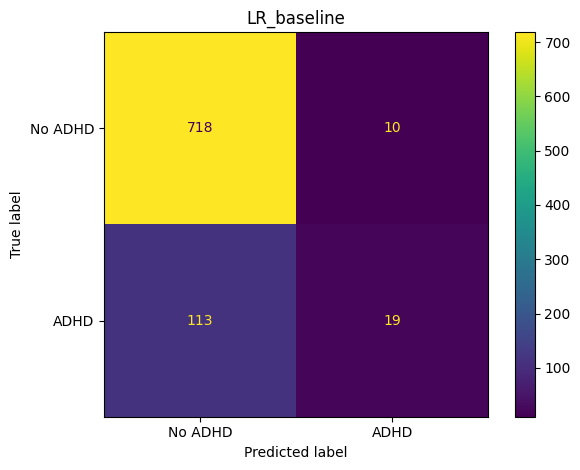


────────────────────────────────────────
LR_balanced
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       728
           1       0.28      0.61      0.38       132

    accuracy                           0.69       860
   macro avg       0.59      0.66      0.59       860
weighted avg       0.81      0.69      0.73       860

ROC-AUC: 0.745 | PR-AUC: 0.382


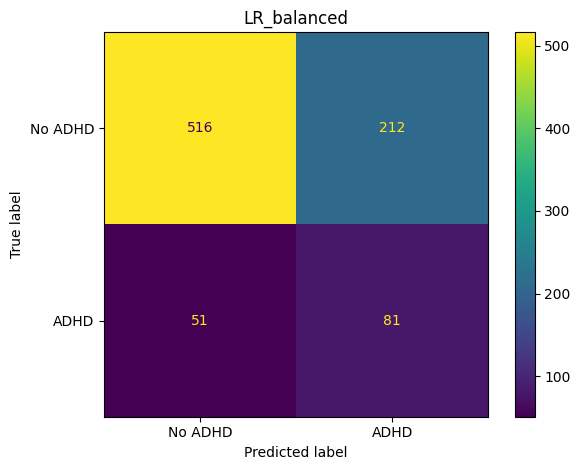


────────────────────────────────────────
LR_weighted
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       728
           1       0.27      0.61      0.38       132

    accuracy                           0.69       860
   macro avg       0.59      0.66      0.59       860
weighted avg       0.81      0.69      0.73       860

ROC-AUC: 0.744 | PR-AUC: 0.383


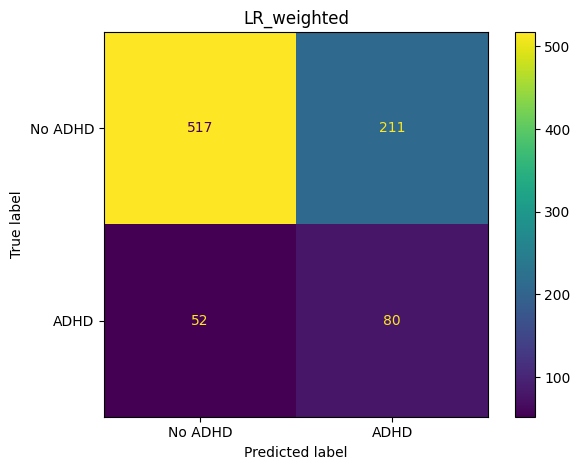


────────────────────────────────────────
LR_smote_only
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       728
           1       0.28      0.61      0.38       132

    accuracy                           0.70       860
   macro avg       0.60      0.66      0.59       860
weighted avg       0.81      0.70      0.74       860

ROC-AUC: 0.741 | PR-AUC: 0.382


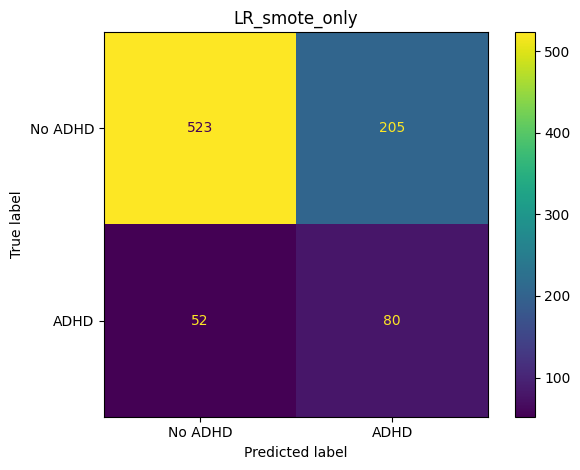


────────────────────────────────────────
LR_combined
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       728
           1       0.28      0.61      0.38       132

    accuracy                           0.70       860
   macro avg       0.60      0.66      0.59       860
weighted avg       0.81      0.70      0.74       860

ROC-AUC: 0.741 | PR-AUC: 0.382


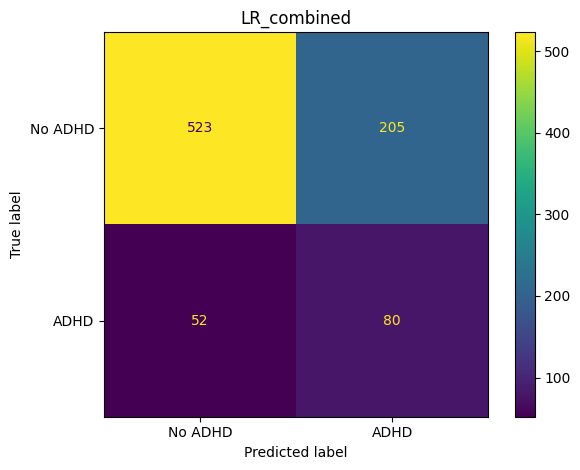


────────────────────────────────────────
Phase2_LR
              precision    recall  f1-score   support

           0       0.91      0.71      0.80       728
           1       0.27      0.61      0.38       132

    accuracy                           0.69       860
   macro avg       0.59      0.66      0.59       860
weighted avg       0.81      0.69      0.73       860

ROC-AUC: 0.744 | PR-AUC: 0.383


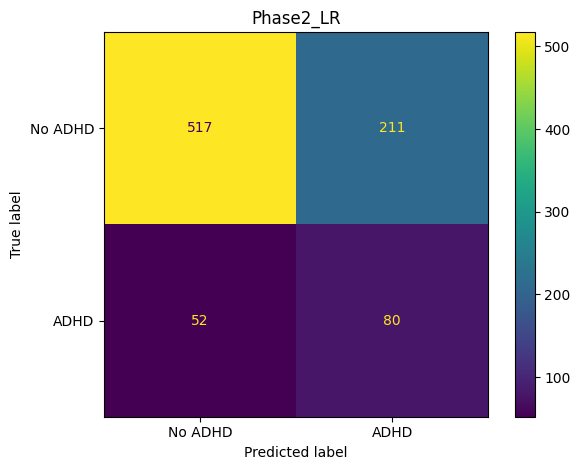


────────────────────────────────────────
Phase2_DT
              precision    recall  f1-score   support

           0       0.93      0.67      0.78       728
           1       0.28      0.71      0.40       132

    accuracy                           0.68       860
   macro avg       0.61      0.69      0.59       860
weighted avg       0.83      0.68      0.72       860

ROC-AUC: 0.722 | PR-AUC: 0.370


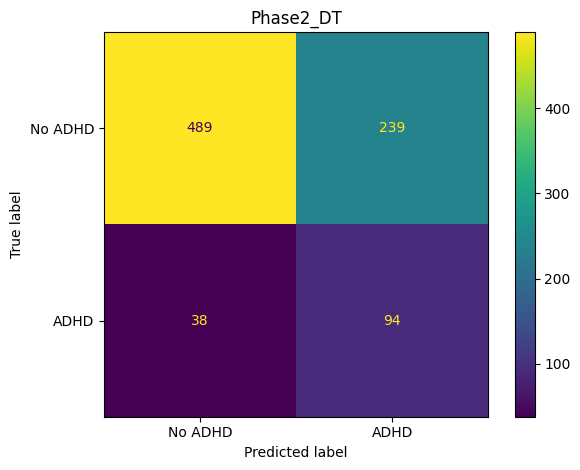


────────────────────────────────────────
Phase2_BNB
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       728
           1       0.28      0.44      0.34       132

    accuracy                           0.74       860
   macro avg       0.58      0.62      0.59       860
weighted avg       0.79      0.74      0.76       860

ROC-AUC: 0.730 | PR-AUC: 0.312


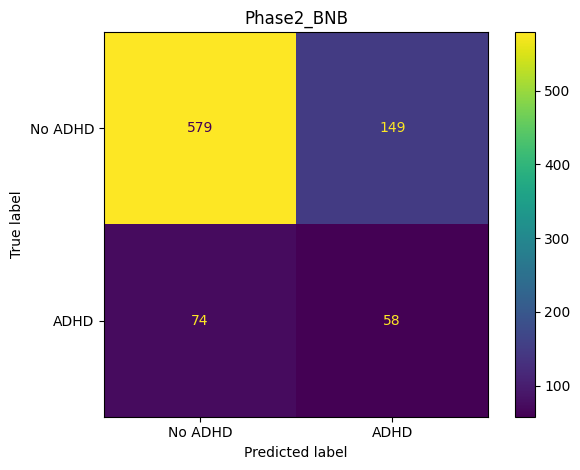

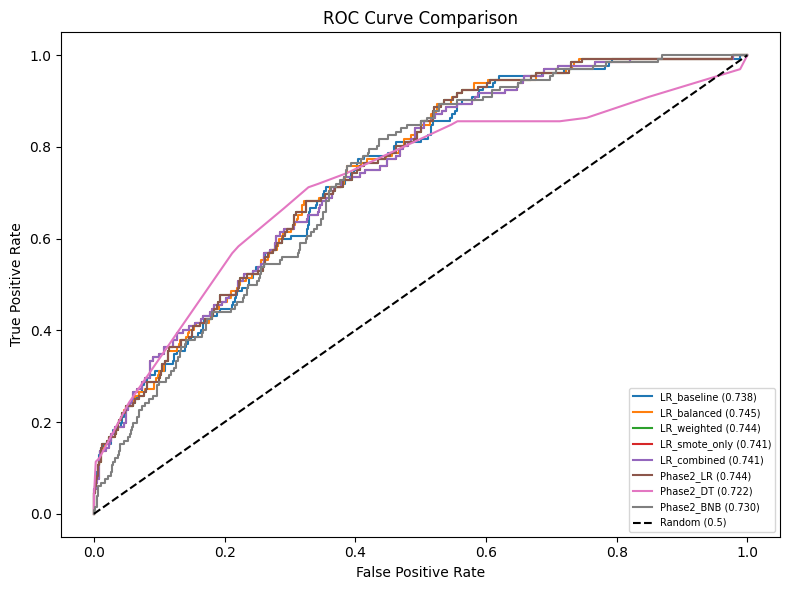

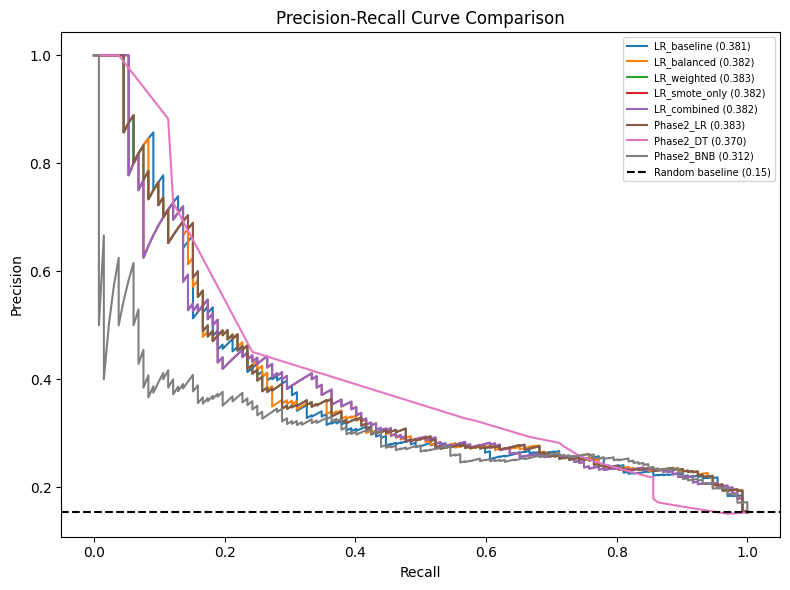

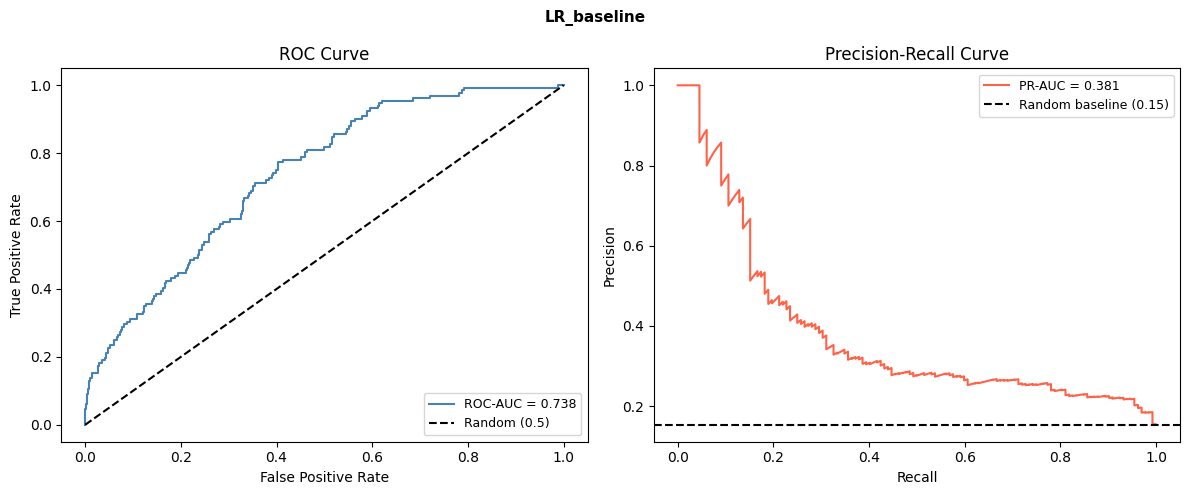

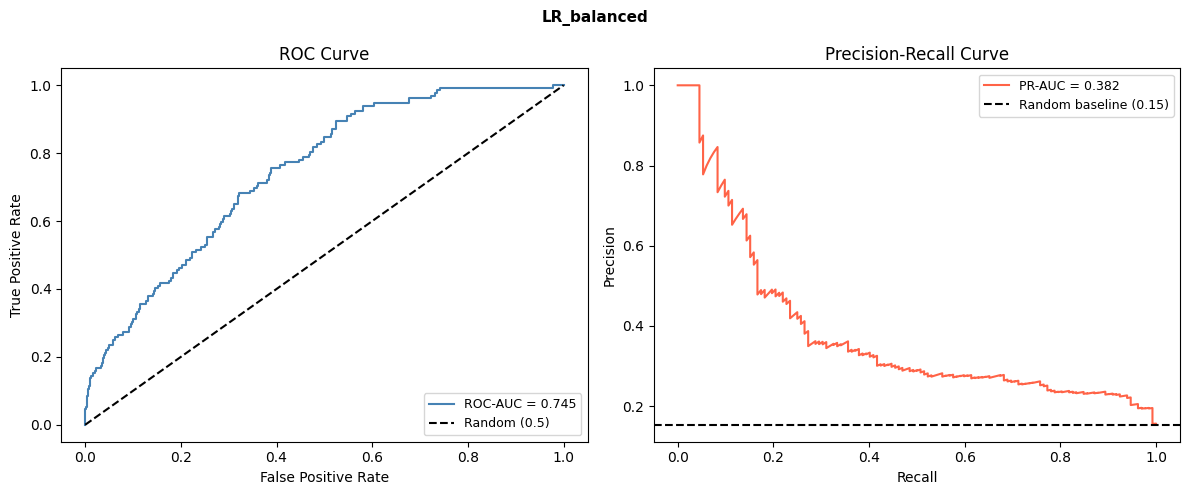

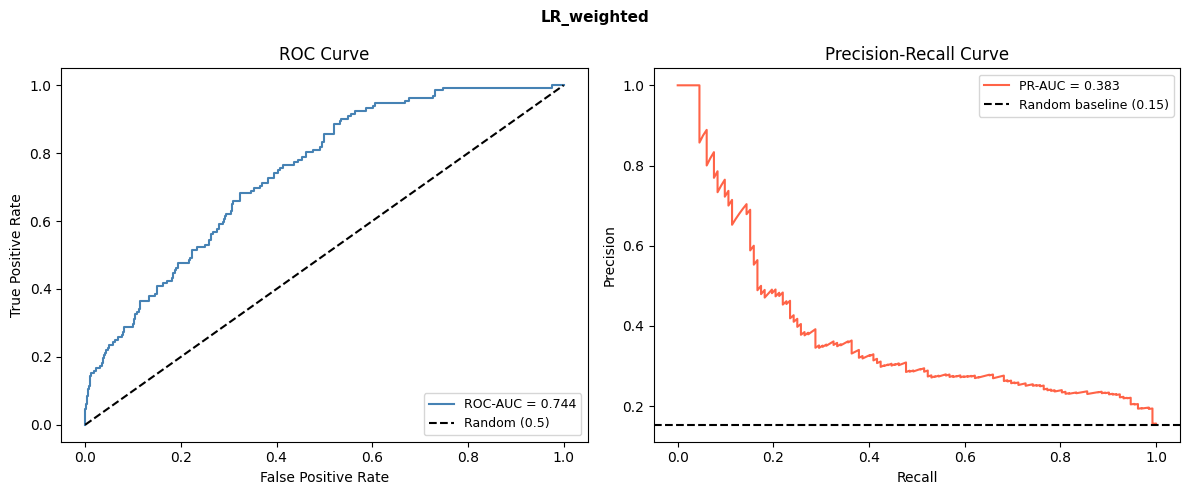

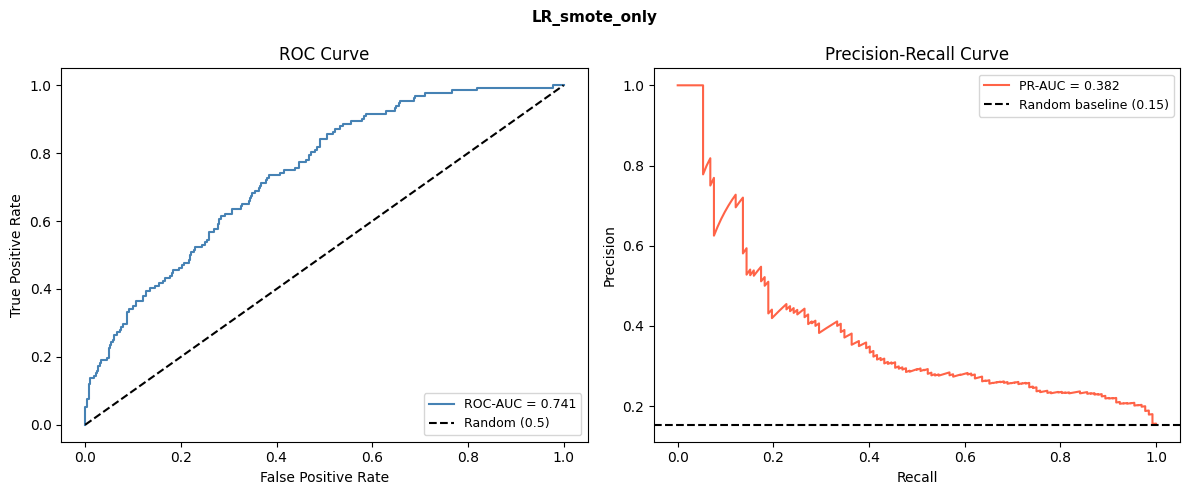

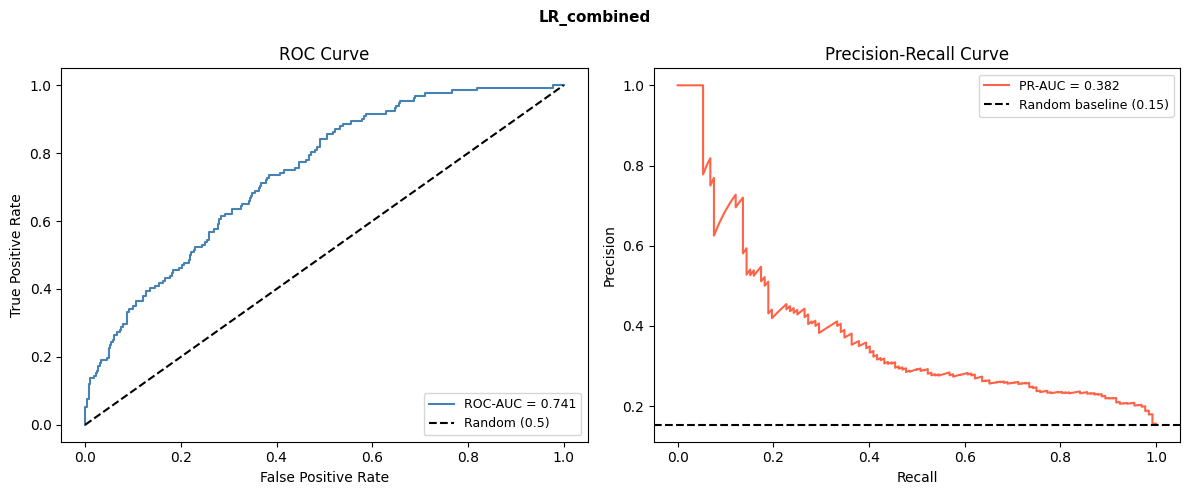

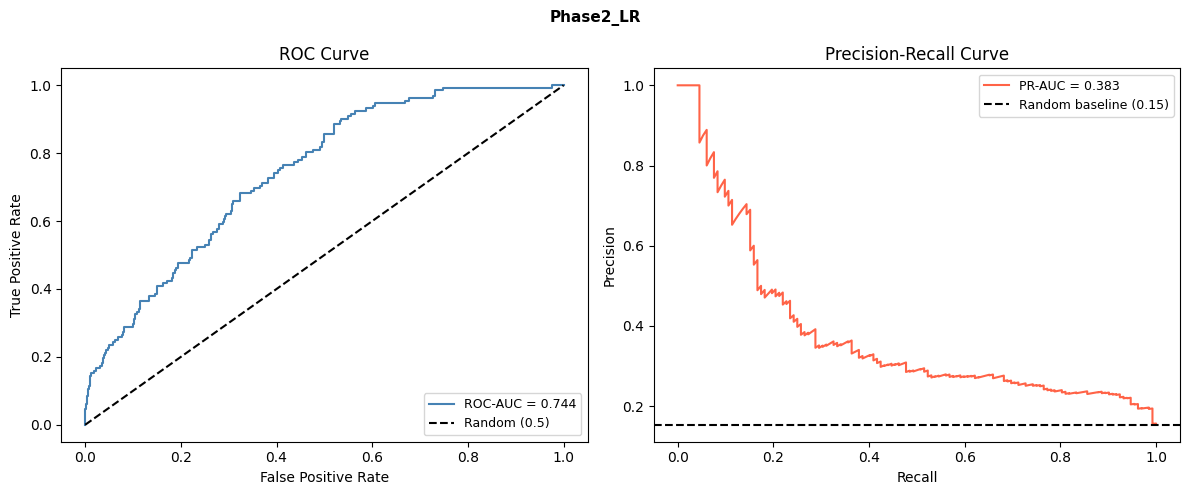

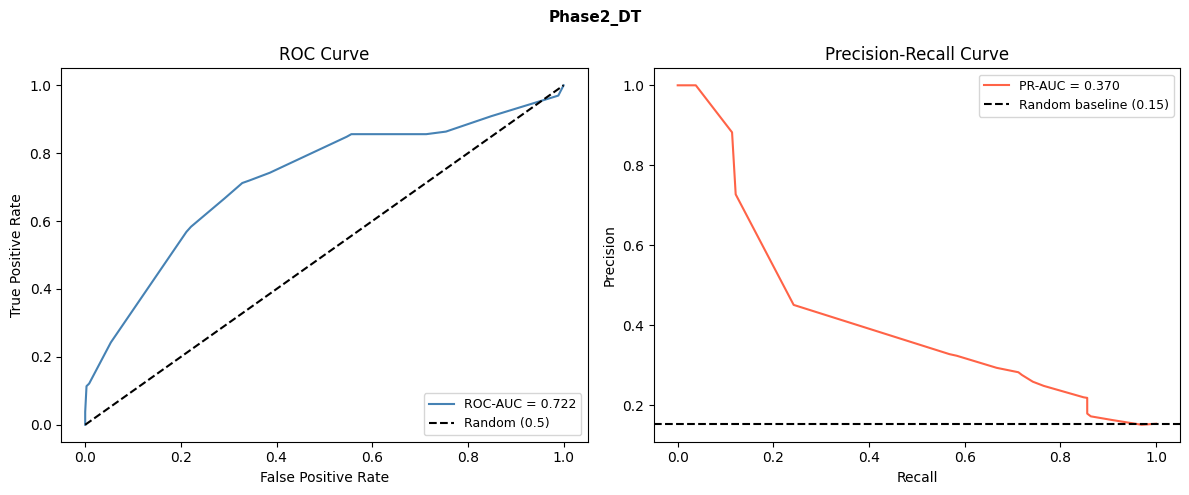

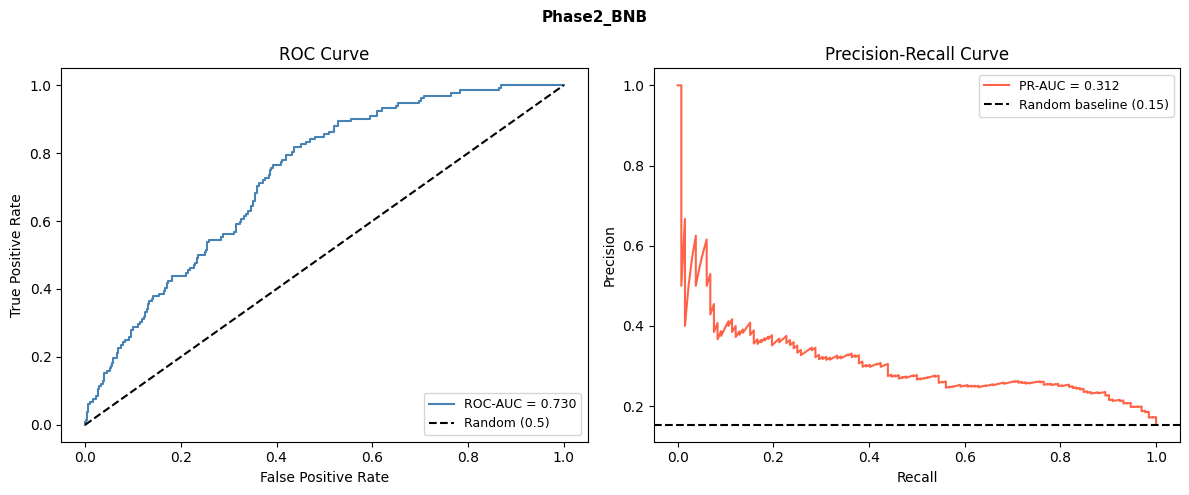


Summary (sorted by PR-AUC, then recall):
        model  accuracy  recall_adhd  precision_adhd  f1_adhd  pr_auc  roc_auc  cv_recall_mean  cv_recall_std
  LR_weighted     0.694        0.606           0.275    0.378   0.383    0.744           0.683          0.038
    Phase2_LR     0.694        0.606           0.275    0.378   0.383    0.744           0.683          0.038
  LR_balanced     0.694        0.614           0.276    0.381   0.382    0.745           0.680          0.041
LR_smote_only     0.701        0.606           0.281    0.384   0.382    0.741           0.645          0.043
  LR_combined     0.701        0.606           0.281    0.384   0.382    0.741           0.645          0.043
  LR_baseline     0.857        0.144           0.655    0.236   0.381    0.738           0.167          0.053
    Phase2_DT     0.678        0.712           0.282    0.404   0.370    0.722           0.723          0.132
   Phase2_BNB     0.741        0.439           0.280    0.342   0.312    0.730

In [13]:
print("TEST SET RESULTS")

# y_test cast once — same for all models
y_test_int = y_test.astype(int)

# Store curve data per model so comparison plots are built fresh after the loop.
# Pre-creating fig/ax before the loop causes Jupyter to render the empty figure
# immediately — by the time curves are added and we call show(), a blank figure
# has already been displayed and the populated one never renders.
results_rows  = []
roc_curve_data = {}   # name → (fpr, tpr, roc_auc_val)
pr_curve_data  = {}   # name → (recall_curve, precision_curve, pr_auc_val)

for name, pipe in trained_models.items():

    y_pred     = pipe.predict(X_test)
    y_prob     = pipe.predict_proba(X_test)[:, 1]
    y_pred_int = y_pred.astype(int)

    # ── Classification report ─────────────────────────────────────────────────
    report         = classification_report(y_test_int, y_pred_int, output_dict=True)
    adhd           = report.get('1', {})
    f1_adhd        = adhd.get('f1-score',  float('nan'))
    recall_adhd    = adhd.get('recall',    float('nan'))
    precision_adhd = adhd.get('precision', float('nan'))

    # ── ROC-AUC ───────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test_int, y_prob)
    roc_auc_val = roc_auc_score(y_test_int, y_prob)

    # ── PR-AUC ────────────────────────────────────────────────────────────────
    # precision_recall_curve returns (precision, recall, thresholds) in that order
    precision_curve, recall_curve, _ = precision_recall_curve(y_test_int, y_prob)
    pr_auc_val = average_precision_score(y_test_int, y_prob)

    # Store curve data for comparison plots built after the loop
    roc_curve_data[name] = (fpr, tpr, roc_auc_val)
    pr_curve_data[name]  = (recall_curve, precision_curve, pr_auc_val)

    results_rows.append({
        'model':          name,
        'accuracy':       round(report['accuracy'], 3),
        'recall_adhd':    round(recall_adhd,    3),
        'precision_adhd': round(precision_adhd, 3),
        'f1_adhd':        round(f1_adhd,        3),
        'pr_auc':         round(pr_auc_val,     3),
        'roc_auc':        round(roc_auc_val,    3),
        'cv_recall_mean': round(cv_results[name].mean(), 3),
        'cv_recall_std':  round(cv_results[name].std(),  3),
    })

    print(f"\n{'─' * 40}\n{name}")
    print(classification_report(y_test_int, y_pred_int))
    print(f"ROC-AUC: {roc_auc_val:.3f} | PR-AUC: {pr_auc_val:.3f}")

    # ── Confusion matrix — individual plot per model ──────────────────────────
    cm = confusion_matrix(y_test_int, y_pred_int)
    fig_cm, ax_cm = plt.subplots()
    ConfusionMatrixDisplay(cm, display_labels=["No ADHD", "ADHD"]).plot(ax=ax_cm)
    ax_cm.set_title(name)
    plt.tight_layout()
    plt.show()
    plt.close(fig_cm)

# ── ROC comparison plot — built fresh after loop ──────────────────────────────
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
for name, (fpr, tpr, roc_auc_val) in roc_curve_data.items():
    ax_roc.plot(fpr, tpr, label=f"{name} ({roc_auc_val:.3f})")
ax_roc.plot([0, 1], [0, 1], "k--", label="Random (0.5)")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve Comparison")
ax_roc.legend(loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()
plt.close(fig_roc)

# ── PR comparison plot — built fresh after loop ───────────────────────────────
# Random baseline ≈ minority class proportion, not 0.5
baseline = y_test_int.mean()
fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
for name, (recall_curve, precision_curve, pr_auc_val) in pr_curve_data.items():
    ax_pr.plot(recall_curve, precision_curve, label=f"{name} ({pr_auc_val:.3f})")
ax_pr.axhline(y=baseline, color="k", linestyle="--",
              label=f"Random baseline ({baseline:.2f})")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curve Comparison")
ax_pr.legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.show()
plt.close(fig_pr)

# ── Individual ROC + PR plots per model ──────────────────────────────────────
for name in roc_curve_data:
    fpr, tpr, roc_auc_val          = roc_curve_data[name]
    recall_curve, prec_curve, pr_auc_val = pr_curve_data[name]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(name, fontsize=11, fontweight="bold")

    # ROC
    ax1.plot(fpr, tpr, color="steelblue", label=f"ROC-AUC = {roc_auc_val:.3f}")
    ax1.plot([0, 1], [0, 1], "k--", label="Random (0.5)")
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title("ROC Curve")
    ax1.legend(loc="lower right", fontsize=9)

    # PR
    ax2.plot(recall_curve, prec_curve, color="tomato", label=f"PR-AUC = {pr_auc_val:.3f}")
    ax2.axhline(y=baseline, color="k", linestyle="--",
                label=f"Random baseline ({baseline:.2f})")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title("Precision-Recall Curve")
    ax2.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Summary table sorted by PR-AUC as primary metric
results_df = (
    pd.DataFrame(results_rows)
    .sort_values(["pr_auc", "recall_adhd"], ascending=False)
)
print("\nSummary (sorted by PR-AUC, then recall):")
print(results_df.to_string(index=False))

Sensitivity Analysis


sklearn DecisionTree only implements pre-pruning (not post-pruning/CCP).<br>
We test three pre-pruning parameters independently (OFAT):

1. max_depth        — limits tree depth (most common lever)
2. min_samples_leaf — minimum samples required at a leaf node
3. max_leaf_nodes   — global cap on total leaves

max_depth=    2 | CV Recall: 0.820 ± 0.090
max_depth=    3 | CV Recall: 0.695 ± 0.035
max_depth=    4 | CV Recall: 0.757 ± 0.107
max_depth=    5 | CV Recall: 0.728 ± 0.122
max_depth=    7 | CV Recall: 0.708 ± 0.036
max_depth=   10 | CV Recall: 0.660 ± 0.027
max_depth=   15 | CV Recall: 0.665 ± 0.035
max_depth= None | CV Recall: 0.665 ± 0.035


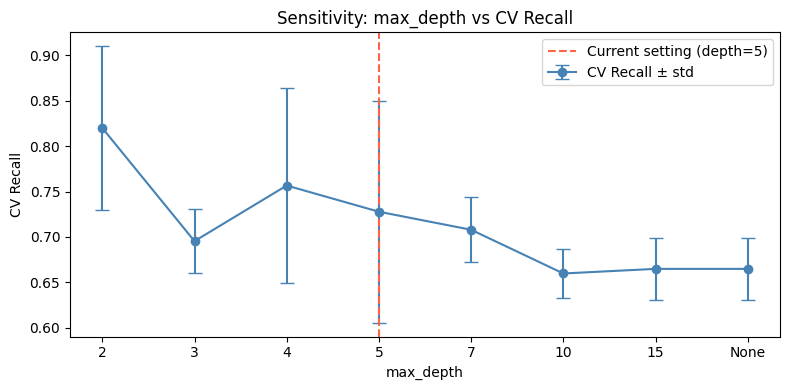

min_samples_leaf=   5 | CV Recall: 0.720 ± 0.127
min_samples_leaf=  10 | CV Recall: 0.733 ± 0.129
min_samples_leaf=  15 | CV Recall: 0.740 ± 0.128
min_samples_leaf=  25 | CV Recall: 0.728 ± 0.122
min_samples_leaf=  50 | CV Recall: 0.690 ± 0.107
min_samples_leaf=  75 | CV Recall: 0.733 ± 0.074
min_samples_leaf= 100 | CV Recall: 0.698 ± 0.079


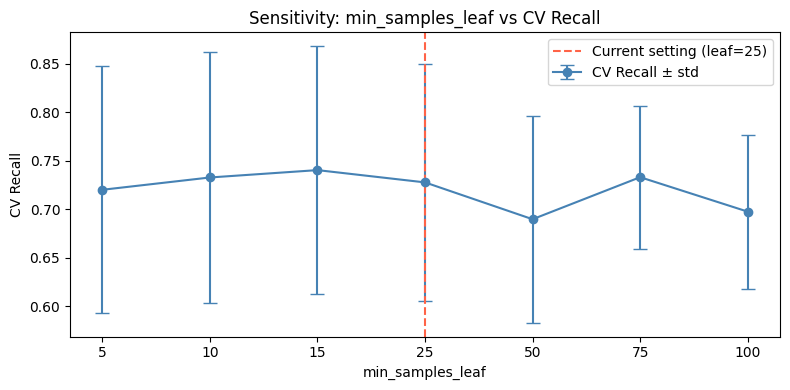

max_leaf_nodes=    5 | CV Recall: 0.795 ± 0.069
max_leaf_nodes=   10 | CV Recall: 0.822 ± 0.028
max_leaf_nodes=   20 | CV Recall: 0.728 ± 0.122
max_leaf_nodes=   30 | CV Recall: 0.728 ± 0.122
max_leaf_nodes=   50 | CV Recall: 0.728 ± 0.122
max_leaf_nodes=   75 | CV Recall: 0.728 ± 0.122
max_leaf_nodes=  100 | CV Recall: 0.728 ± 0.122
max_leaf_nodes= None | CV Recall: 0.728 ± 0.122


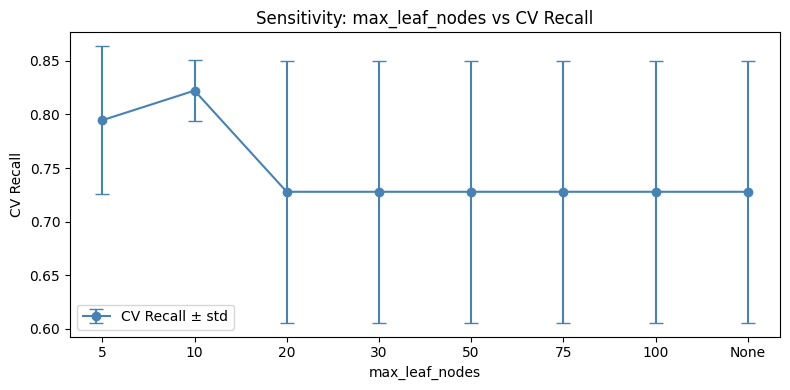

In [14]:
# Extract prep step from best pipeline for consistent preprocessing
best_pipe = trained_models["Phase2_DT"]
prep      = best_pipe.named_steps["prep"]
X_train_t = prep.transform(X_train)
X_test_t  = prep.transform(X_test)
feature_names_out = prep.get_feature_names_out()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── 1. max_depth sensitivity ──────────────────────────────────────────────────
depth_values = [2, 3, 4, 5, 7, 10, 15, None]
depth_recall_mean, depth_recall_std = [], []

for d in depth_values:
    dt = DecisionTreeClassifier(
        max_depth=d, min_samples_leaf=25,
        class_weight={0: 1, 1: customised_weight},
        random_state=RANDOM_STATE
    )
    scores = cross_val_score(dt, X_train_t, y_train, cv=skf, scoring="recall", n_jobs=1)
    depth_recall_mean.append(scores.mean())
    depth_recall_std.append(scores.std())
    print(f"max_depth={str(d):>5} | CV Recall: {scores.mean():.3f} ± {scores.std():.3f}")

depth_labels = [str(d) if d is not None else "None" for d in depth_values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(depth_labels, depth_recall_mean, yerr=depth_recall_std,
            marker='o', capsize=5, color="steelblue", label="CV Recall ± std")
ax.axvline(x=depth_labels.index("5"), color="tomato", linestyle="--",
           label="Current setting (depth=5)")
ax.set_xlabel("max_depth")
ax.set_ylabel("CV Recall")
ax.set_title("Sensitivity: max_depth vs CV Recall")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

# ── 2. min_samples_leaf sensitivity ──────────────────────────────────────────
leaf_values = [5, 10, 15, 25, 50, 75, 100]
leaf_recall_mean, leaf_recall_std = [], []

for l in leaf_values:
    dt = DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=l,
        class_weight={0: 1, 1: customised_weight},
        random_state=RANDOM_STATE
    )
    scores = cross_val_score(dt, X_train_t, y_train, cv=skf, scoring="recall", n_jobs=1)
    leaf_recall_mean.append(scores.mean())
    leaf_recall_std.append(scores.std())
    print(f"min_samples_leaf={l:>4} | CV Recall: {scores.mean():.3f} ± {scores.std():.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar([str(l) for l in leaf_values], leaf_recall_mean, yerr=leaf_recall_std,
            marker='o', capsize=5, color="steelblue", label="CV Recall ± std")
ax.axvline(x=[str(l) for l in leaf_values].index("25"), color="tomato", linestyle="--",
           label="Current setting (leaf=25)")
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("CV Recall")
ax.set_title("Sensitivity: min_samples_leaf vs CV Recall")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

# ── 3. max_leaf_nodes sensitivity ─────────────────────────────────────────────
node_values = [5, 10, 20, 30, 50, 75, 100, None]
node_recall_mean, node_recall_std = [], []

for n in node_values:
    dt = DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=25, max_leaf_nodes=n,
        class_weight={0: 1, 1: customised_weight},
        random_state=RANDOM_STATE
    )
    scores = cross_val_score(dt, X_train_t, y_train, cv=skf, scoring="recall", n_jobs=1)
    node_recall_mean.append(scores.mean())
    node_recall_std.append(scores.std())
    label = str(n) if n is not None else "None"
    print(f"max_leaf_nodes={label:>5} | CV Recall: {scores.mean():.3f} ± {scores.std():.3f}")

node_labels = [str(n) if n is not None else "None" for n in node_values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(node_labels, node_recall_mean, yerr=node_recall_std,
            marker='o', capsize=5, color="steelblue", label="CV Recall ± std")
ax.set_xlabel("max_leaf_nodes")
ax.set_ylabel("CV Recall")
ax.set_title("Sensitivity: max_leaf_nodes vs CV Recall")
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

Apply best setting to Decision tree OFAT to see which parameter helps better

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Define the four configurations from your table ───────────────────────────

configurations = [
    {
        "name": "No tuning (original)",
        "max_depth": 5,
        "min_samples_leaf": 25,
        "max_leaf_nodes": None
    },
    {
        "name": "Yes - max_leaf_nodes=10",
        "max_depth": 5,
        "min_samples_leaf": 25,
        "max_leaf_nodes": 10
    },
    {
        "name": "Yes - min_samples_leaf=15",
        "max_depth": 5,
        "min_samples_leaf": 15,
        "max_leaf_nodes": None
    },
    {
        "name": "Yes - both changes",
        "max_depth": 5,
        "min_samples_leaf": 15,
        "max_leaf_nodes": 10
    }
]

# ── Run cross-validation for each configuration ──────────────────────────────

results = []

for config in configurations:
    print(f"\nEvaluating: {config['name']}")
    print(f"  max_depth       = {config['max_depth']}")
    print(f"  min_samples_leaf = {config['min_samples_leaf']}")
    print(f"  max_leaf_nodes   = {config['max_leaf_nodes']}")

    dt = DecisionTreeClassifier(
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_leaf_nodes=config["max_leaf_nodes"],
        class_weight={0: 1, 1: customised_weight},
        random_state=RANDOM_STATE
    )

    scores = cross_val_score(
        dt,
        X_train_t,
        y_train,
        cv=skf,
        scoring="recall",          # recall for positive class (ADHD=1)
        n_jobs=-1
    )

    mean_recall = scores.mean()
    std_recall  = scores.std()

    print(f"  → CV Recall: {mean_recall:.4f} ± {std_recall:.4f}")

    results.append({
        "Tuning": "No" if "original" in config["name"].lower() else "Yes",
        "max_depth": config["max_depth"],
        "min_samples_leaf": config["min_samples_leaf"],
        "max_leaf_nodes": config["max_leaf_nodes"] if config["max_leaf_nodes"] is not None else "None",
        "CV Recall": round(mean_recall, 4),
        "CV Recall std": round(std_recall, 4)
    })

# ── Show results in a nice table ─────────────────────────────────────────────

results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("Summary of CV Recall Results")
print("="*70)
print(results_df.to_string(index=False))


Evaluating: No tuning (original)
  max_depth       = 5
  min_samples_leaf = 25
  max_leaf_nodes   = None
  → CV Recall: 0.7278 ± 0.1223

Evaluating: Yes - max_leaf_nodes=10
  max_depth       = 5
  min_samples_leaf = 25
  max_leaf_nodes   = 10
  → CV Recall: 0.8223 ± 0.0282

Evaluating: Yes - min_samples_leaf=15
  max_depth       = 5
  min_samples_leaf = 15
  max_leaf_nodes   = None
  → CV Recall: 0.7405 ± 0.1278

Evaluating: Yes - both changes
  max_depth       = 5
  min_samples_leaf = 15
  max_leaf_nodes   = 10
  → CV Recall: 0.8273 ± 0.0359

Summary of CV Recall Results
Tuning  max_depth  min_samples_leaf max_leaf_nodes  CV Recall  CV Recall std
    No          5                25           None     0.7278         0.1223
   Yes          5                25             10     0.8223         0.0282
   Yes          5                15           None     0.7405         0.1278
   Yes          5                15             10     0.8273         0.0359


Training curve plot

H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['sales'] will be ignored
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['hr'] will be ignored
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['hr'] will be ignored
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['hr'] will be ignored
  warnings.warn(
H:\My Drive\Courses\Term 4\Milestone 2\Part A\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['hr'] will be ignored
  warnings.warn(


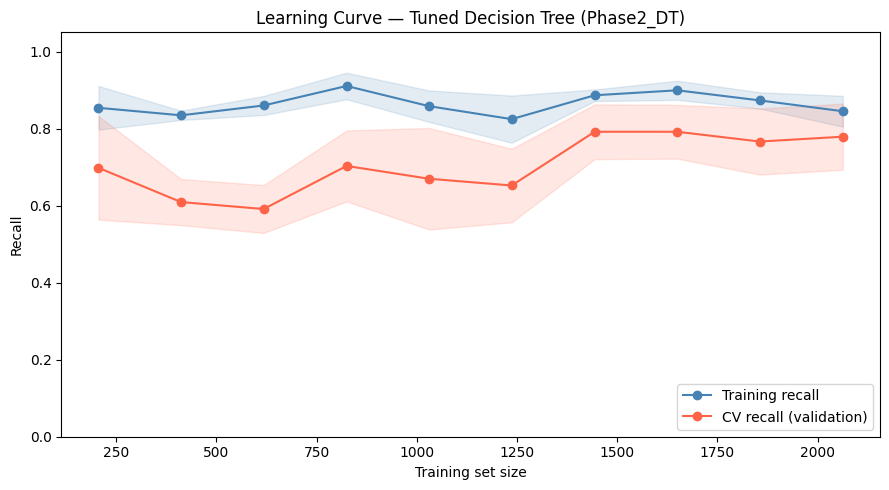

In [16]:
pipe = trained_models["Phase2_DT"]

train_sizes, train_scores, val_scores = learning_curve(
    pipe,
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="recall",
    n_jobs=1,                    # n_jobs=1 avoids MLBTransformer serialisation issues
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, train_mean, "o-", color="steelblue", label="Training recall")
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color="steelblue")

ax.plot(train_sizes, val_mean, "o-", color="tomato", label="CV recall (validation)")
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color="tomato")

ax.set_xlabel("Training set size")
ax.set_ylabel("Recall")
ax.set_title("Learning Curve — Tuned Decision Tree (Phase2_DT)")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()
plt.close(fig)

Feature importance

FEATURE IMPORTANCE
DT models found: ['Phase2_DT']

Top 10 features (importance) — Phase2_DT:
addictive                       0.269009
continent_work                  0.242460
mood                            0.122855
willing_share_family            0.121019
mh_treatment_history            0.050199
family_history_mh               0.041606
observed_coworker_discuss_mh    0.032095
anxiety                         0.031705
open_to_discuss_coworkers       0.022564
company_size                    0.015857


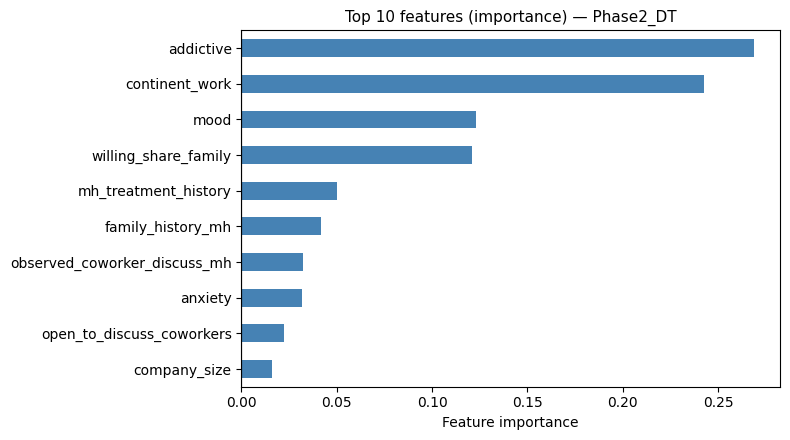

In [17]:
print("FEATURE IMPORTANCE")

# Scan trained_models for LR and DT — works with any naming convention
dt_candidates = [k for k in trained_models if "DT" in k or "DecisionTree" in k]

print(f"DT models found: {dt_candidates}")

for name in dt_candidates:
    pipe = trained_models[name]
    feature_names = get_feature_names_from_pipe(pipe)
    if feature_names is not None:
        plot_feature_importance(name, pipe, feature_names, top_n=10)

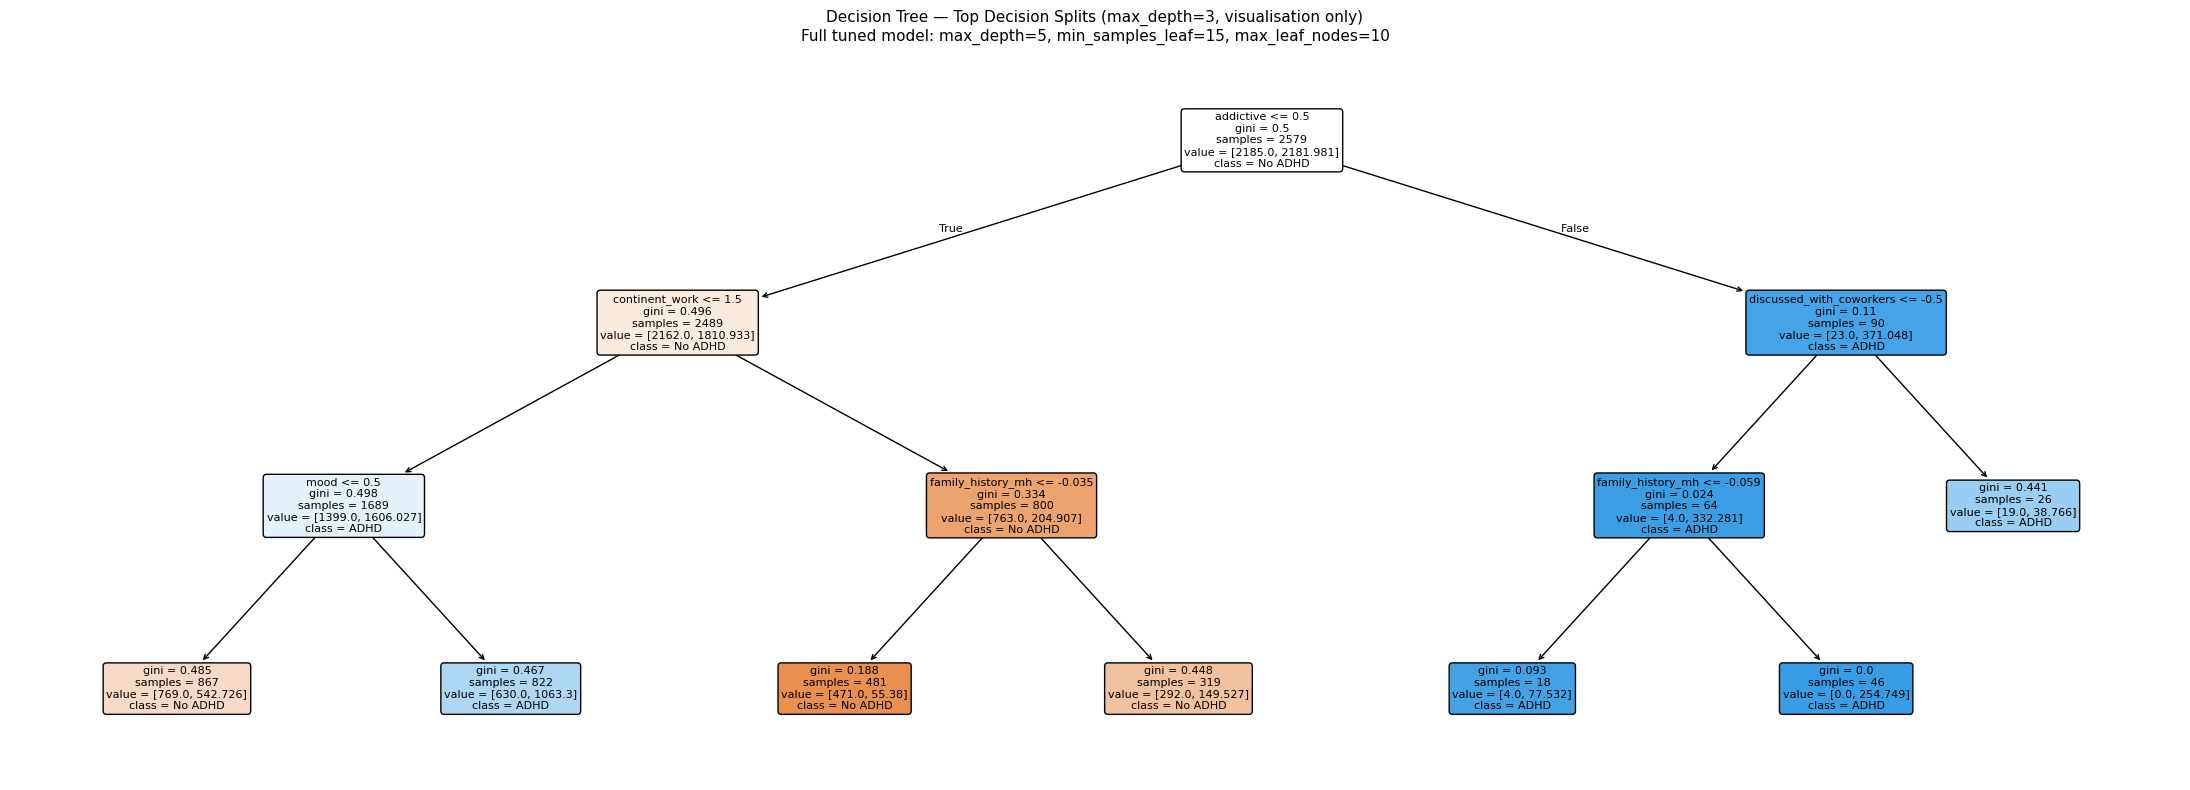

In [18]:
pipe              = trained_models["Phase2_DT"]
dt_model          = pipe.named_steps["model"]
prep              = pipe.named_steps["prep"]
X_train_t         = prep.transform(X_train)
feature_names_out = list(prep.get_feature_names_out())

# Refit at depth=3 for inline visualisation only
# (the full tuned tree at depth=5 is too dense to read inline)
dt_viz = DecisionTreeClassifier(
    max_depth        = 3,
    min_samples_leaf = 15,
    max_leaf_nodes   = 10,
    class_weight     = {0: 1, 1: customised_weight},
    random_state     = RANDOM_STATE
)
dt_viz.fit(X_train_t, y_train)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_viz,
    feature_names = feature_names_out,
    class_names   = ["No ADHD", "ADHD"],
    filled        = True,    # colour nodes by majority class
    rounded       = True,
    impurity      = True,    # show Gini impurity
    proportion    = False,   # show raw sample counts
    fontsize      = 8,
    ax            = ax
)
ax.set_title(
    "Decision Tree — Top Decision Splits (max_depth=3, visualisation only)\n"
    "Full tuned model: max_depth=5, min_samples_leaf=15, max_leaf_nodes=10",
    fontsize=11
)
plt.tight_layout()
plt.show()
plt.close(fig)


Failure Analysis - SHAP waterfall plot

SHAP sanity check: sum=0.1727, f(x)-E[f(x)]=0.1727, match=True
Base value E[f(x)] = 0.4997  (population ADHD rate in model)

False negatives : 38
False positives : 239

── Instance 1: False Negative (genuine ADHD case missed) ──
   P(ADHD)=0.113 | True=1, Pred=0


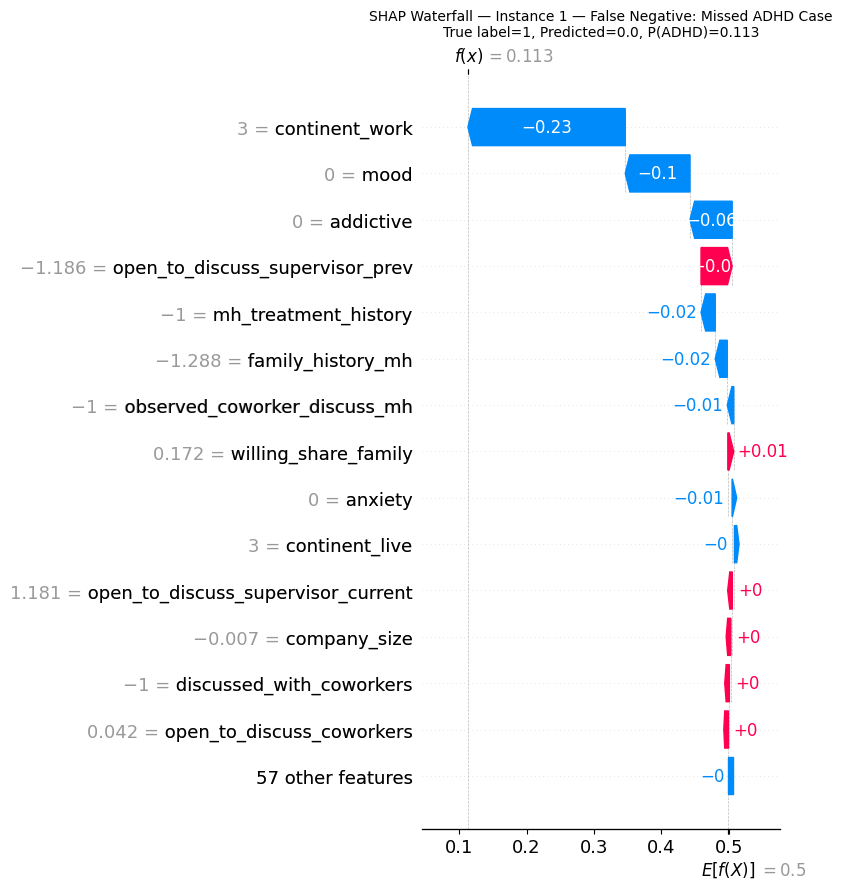


── Instance 2: False Positive (non-ADHD flagged as ADHD) ──
   P(ADHD)=0.672 | True=0, Pred=1


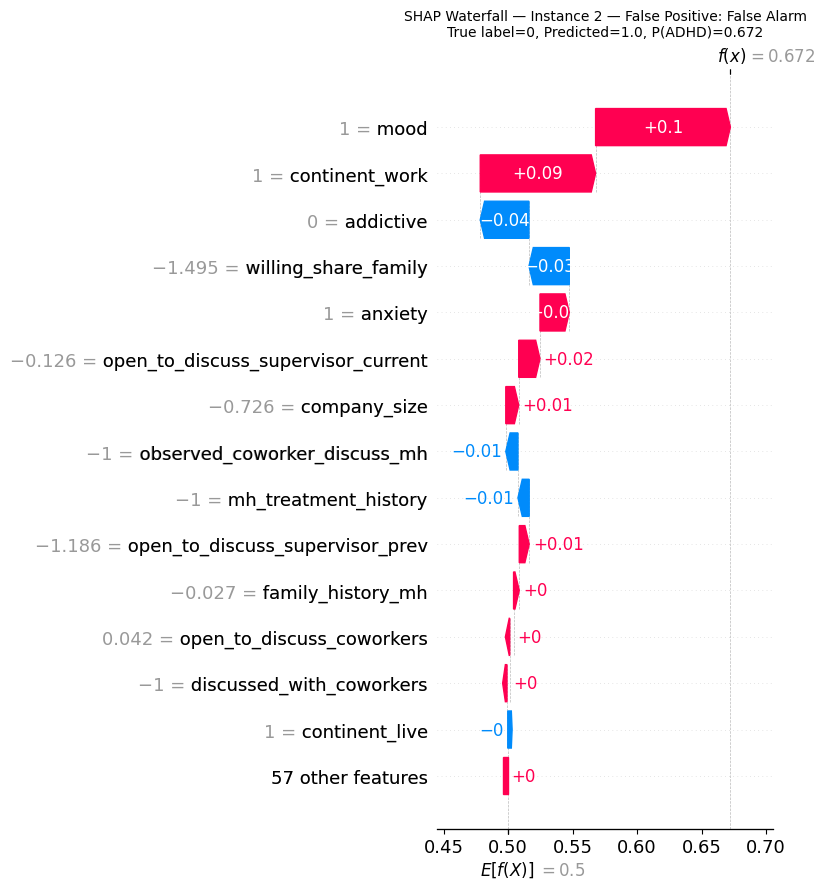


── Instance 3: False Negative with addictive=1 ──
   No false negatives with addictive=1 found — using second FN
   P(ADHD)=0.094 | True=1, Pred=0


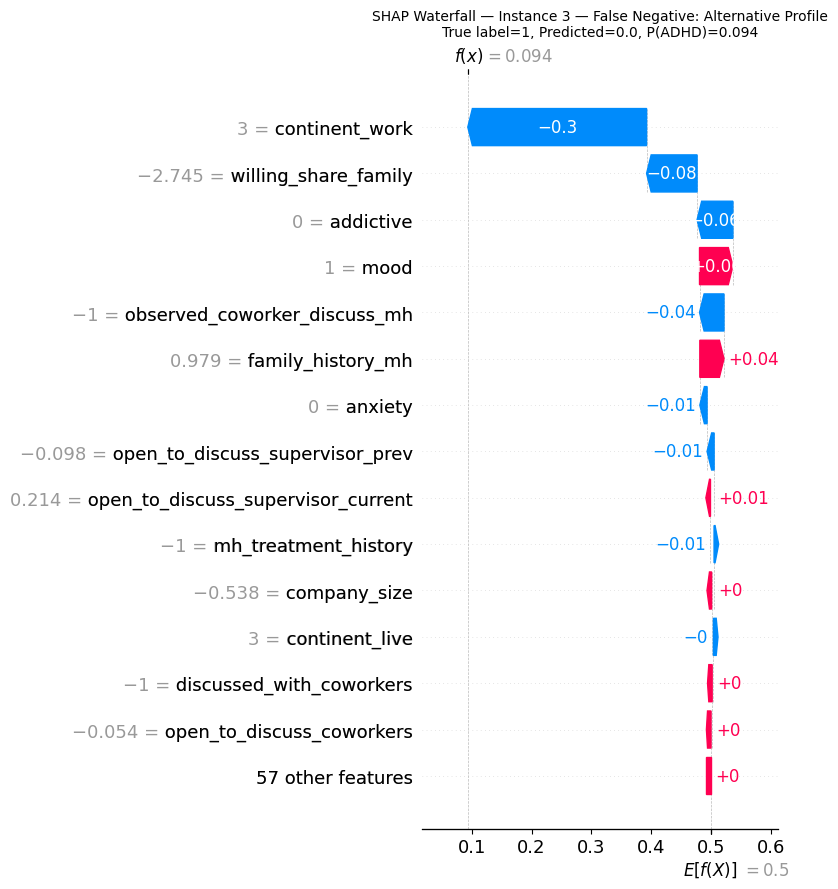

In [19]:
pipe              = trained_models["Phase2_DT"]
dt_model          = pipe.named_steps["model"]
prep              = pipe.named_steps["prep"]
feature_names_out = list(prep.get_feature_names_out())

# Transform full test set first — select instances by index afterwards
X_test_t   = prep.transform(X_test)
y_test_int = y_test.astype(int).values
y_pred     = pipe.predict(X_test)
y_prob     = pipe.predict_proba(X_test)[:, 1]

# Build TreeExplainer — exact SHAP values, no approximation needed for DT
explainer   = shap.TreeExplainer(dt_model)
shap_values = explainer.shap_values(X_test_t)

# Normalise to class-1 (ADHD positive) SHAP array
# Older SHAP (<0.40) returns list [class0_arr, class1_arr]
# Newer SHAP returns 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    sv_class1 = shap_values[1]
else:
    sv_class1 = shap_values[:, :, 1]

# Base value for ADHD class
base_val = (explainer.expected_value[1]
            if isinstance(explainer.expected_value, (list, np.ndarray))
            else explainer.expected_value)

# ── Sanity check: SHAP values should sum to f(x) - E[f(x)] ──────────────────
idx      = 0
shap_sum = sv_class1[idx].sum()
fx       = y_prob[idx]
match    = abs(shap_sum - (fx - base_val)) < 0.01
print(f"SHAP sanity check: sum={shap_sum:.4f}, "
      f"f(x)-E[f(x)]={fx - base_val:.4f}, match={match}")
print(f"Base value E[f(x)] = {base_val:.4f}  (population ADHD rate in model)")
if not match:
    print("WARNING: SHAP values do not sum correctly — check shap version")
print()

# ── Identify instance positions ──────────────────────────────────────────────
fn_pos = np.where((y_test_int == 1) & (y_pred == 0))[0]   # false negatives
fp_pos = np.where((y_test_int == 0) & (y_pred == 1))[0]   # false positives
print(f"False negatives : {len(fn_pos)}")
print(f"False positives : {len(fp_pos)}")

# ── Waterfall plot helper ─────────────────────────────────────────────────────
def plot_shap_waterfall(pos, label):
    explanation = shap.Explanation(
        values        = sv_class1[pos],
        base_values   = base_val,
        data          = X_test_t[pos],
        feature_names = feature_names_out
    )
    shap.plots.waterfall(explanation, max_display=15, show=False)
    plt.title(
        f"SHAP Waterfall — {label}\n"
        f"True label={y_test_int[pos]}, Predicted={y_pred[pos]}, "
        f"P(ADHD)={y_prob[pos]:.3f}",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()
    plt.close()

# ── Instance 1: False Negative ────────────────────────────────────────────────
print("\n── Instance 1: False Negative (genuine ADHD case missed) ──")
print(f"   P(ADHD)={y_prob[fn_pos[0]]:.3f} | True=1, Pred=0")
plot_shap_waterfall(fn_pos[0], "Instance 1 — False Negative: Missed ADHD Case")

# ── Instance 2: False Positive ────────────────────────────────────────────────
print("\n── Instance 2: False Positive (non-ADHD flagged as ADHD) ──")
print(f"   P(ADHD)={y_prob[fp_pos[0]]:.3f} | True=0, Pred=1")
plot_shap_waterfall(fp_pos[0], "Instance 2 — False Positive: False Alarm")

# ── Instance 3: False Negative with addictive disorder present ───────────────
# A more interesting false negative than Instance 1 — the model missed this
# respondent even though addictive disorder (top feature, importance 0.27) is present.
# This shows the geographic prior can override even the strongest signal feature.
print("\n── Instance 3: False Negative with addictive=1 ──")

# Find column index for addictive in the transformed feature set
try:
    addictive_idx = feature_names_out.index("addictive")
    fn_addictive  = np.where(
        (y_test_int == 1) &
        (y_pred == 0) &
        (X_test_t[:, addictive_idx] > 0)
    )[0]

    if len(fn_addictive) > 0:
        print(f"   Found {len(fn_addictive)} false negatives with addictive=1")
        print(f"   P(ADHD)={y_prob[fn_addictive[0]]:.3f} | True=1, Pred=0")
        plot_shap_waterfall(
            fn_addictive[0],
            "Instance 3 — False Negative: ADHD with Addictive Disorder Present"
        )
    else:
        # Fallback: second false negative if available
        print("   No false negatives with addictive=1 found — using second FN")
        if len(fn_pos) > 1:
            print(f"   P(ADHD)={y_prob[fn_pos[1]]:.3f} | True=1, Pred=0")
            plot_shap_waterfall(fn_pos[1], "Instance 3 — False Negative: Alternative Profile")
        else:
            print("   Only one false negative available — skipping Instance 3")

except ValueError:
    # addictive not in feature list under that exact name — search for it
    matches = [i for i, n in enumerate(feature_names_out) if "addictive" in n]
    if matches:
        print(f"   'addictive' found at index {matches[0]}: {feature_names_out[matches[0]]}")
    else:
        print("   'addictive' column not found in transformed features")

No ablation (baseline)              | CV Recall: 0.822 ± 0.043
Geographic features                 | CV Recall: 0.746 ± 0.081 | Δ -0.076
Workplace disclosure features       | CV Recall: 0.779 ± 0.023 | Δ -0.043
Comorbidity features                | CV Recall: 0.731 ± 0.072 | Δ -0.091


                Ablated Group  CV Recall  Std Dev Δ Recall
       No ablation (baseline)      0.822    0.043        —
          Geographic features      0.746    0.081   -0.076
Workplace disclosure features      0.779    0.023   -0.043
         Comorbidity features      0.731    0.072   -0.091


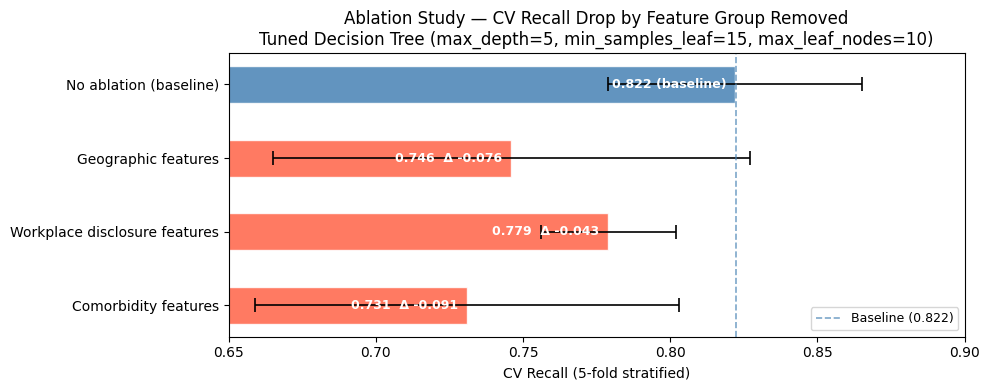

In [20]:
skf_abl = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Comorbidity group — subset of MH_SIGNAL used in feature importance
COMORBIDITY_COL = [
    "addictive", "mood", "anxiety", "ptsd", "ocd",
    "eating", "dissociative", "psychotic", "personality"
]

# The following dictionaries are used for ablation study or test
GEO_COL = [
    'continent_work',
    'continent_live'
]

WORKPLACE_COL =[
    'willing_share_family',
    'observed_coworker_discuss_mh',
    'mh_treatment_history',
]


ablation_groups = {
    "No ablation (baseline)":        [],
    "Geographic features":            GEO_COL,
    "Workplace disclosure features":  WORKPLACE_COL,
    "Comorbidity features":           COMORBIDITY_COL,
}

ablation_results = []
baseline_recall  = None

for group_name, cols_to_drop in ablation_groups.items():

    # Only drop columns that exist in X_train
    cols_present = [c for c in cols_to_drop if c in X_train.columns]
    X_abl        = X_train.drop(columns=cols_present)

    # Reclassify columns for the ablated feature set
    binary_abl, categorical_abl, ordinal_abl, job_abl = classify_columns(X_abl)

    # Rebuild preprocessor with same transformers as main pipeline
    transformers_abl = [
        ("binary",      Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))]),
                        binary_abl),
        ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                  ("encoder", OrdinalEncoder(
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-2))]),
                        categorical_abl),
        ("ordinal",     Pipeline([("imputer", IterativeImputer(
                                      max_iter=20, random_state=RANDOM_STATE)),
                                  ("scaler",  StandardScaler())]),
                        ordinal_abl),
    ]
    if job_abl:
        transformers_abl.append(("job_spec", MLBTransformer(), job_abl))

    prep_abl = ColumnTransformer(
        transformers_abl,
        remainder="drop",
        verbose_feature_names_out=False
    )

    # Same tuned DT configuration as the final model
    dt_abl = DecisionTreeClassifier(
        max_depth        = 5,
        min_samples_leaf = 15,
        max_leaf_nodes   = 10,
        class_weight     = {0: 1, 1: customised_weight},
        random_state     = RANDOM_STATE
    )

    pipe_abl = Pipeline([("prep", prep_abl), ("model", dt_abl)])

    scores = cross_val_score(
        pipe_abl, X_abl, y_train,
        cv=skf_abl, scoring="recall",
        n_jobs=1   # n_jobs=1 for MLBTransformer compatibility
    )

    mean_recall = scores.mean()
    std_recall  = scores.std()

    if baseline_recall is None:
        baseline_recall = mean_recall
        delta_str = "—"
    else:
        delta      = mean_recall - baseline_recall
        delta_str  = f"{delta:+.3f}"

    ablation_results.append({
        "Ablated Group":    group_name,
        "Features Removed": ", ".join(cols_present) if cols_present else "None",
        "CV Recall":        round(mean_recall, 3),
        "Std Dev":          round(std_recall,  3),
        "Δ Recall":         delta_str,
    })

    print(f"{group_name:<35} | CV Recall: {mean_recall:.3f} ± {std_recall:.3f}"
          + (f" | Δ {delta_str}" if delta_str != "—" else ""))

# ── Results table ─────────────────────────────────────────────────────────────
print("\n")
abl_df = pd.DataFrame(ablation_results)
print(abl_df[["Ablated Group", "CV Recall", "Std Dev", "Δ Recall"]].to_string(index=False))

# ── Horizontal bar chart ──────────────────────────────────────────────────────
labels  = abl_df["Ablated Group"].tolist()
recalls = abl_df["CV Recall"].tolist()
stds    = abl_df["Std Dev"].tolist()
deltas  = abl_df["Δ Recall"].tolist()
colors  = ["steelblue"] + ["tomato"] * (len(labels) - 1)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    labels, recalls, xerr=stds,
    color=colors, capsize=5, alpha=0.85, edgecolor="white", height=0.5,
    error_kw=dict(elinewidth=1.2, capthick=1.2)
)

# Annotate INSIDE bars (right-aligned, white text) to avoid overlap with error bars
for bar, recall, delta in zip(bars, recalls, deltas):
    label = f"{recall:.3f} (baseline)" if delta == "—" else f"{recall:.3f}  Δ {delta}"
    ax.text(
        bar.get_width() - 0.003,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center", ha="right",
        fontsize=9, color="white", fontweight="bold"
    )

ax.axvline(
    x=baseline_recall, color="steelblue",
    linestyle="--", linewidth=1.2, alpha=0.7,
    label=f"Baseline ({baseline_recall:.3f})"
)
ax.invert_yaxis()   # baseline at top for natural reading order
ax.set_xlabel("CV Recall (5-fold stratified)")
ax.set_title("Ablation Study — CV Recall Drop by Feature Group Removed\n"
             "Tuned Decision Tree (max_depth=5, min_samples_leaf=15, max_leaf_nodes=10)")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(0.65, 0.90)
plt.tight_layout()
plt.show()
plt.close(fig)